# Ouvidoria Inteligente · Entrega 1
## Esparso × denso: BoW, TF-IDF e embeddings frente a frente

A triagem atual da ouvidoria compara palavras-chave. A pergunta deste notebook é simples: **quando duas manifestações falam do mesmo problema com palavras diferentes, cada representação percebe?**

Três pares do enunciado servem de teste:
- **M003 × M017**: buraco na Av. Brasil × asfalto esburacado da avenida principal (deveria dar **alto**)
- **M008 × M022**: posto de saúde sem médico × falta atendimento no PSF (deveria dar **alto**)
- **M008 × M031**: posto de saúde sem médico × lâmpada queimada na praça (deveria dar **baixo**)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nucleo_ouvidoria as nucleo

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 110)

base = nucleo.carregar_manifestacoes()
pos = {m: i for i, m in enumerate(base["id"])}
base.groupby("categoria_oficial").size().rename("manifestações").to_frame()

,manifestações
categoria_oficial,
educação,8
infraestrutura,9
meio ambiente,8
saúde,8
segurança,7


### Parte A · Construindo as quatro representações
Para BoW e TF-IDF, o texto passa por minúsculas, remoção de acentos e de stopwords. Para os embeddings, usamos um modelo multilíngue (o recomendado) e um treinado em inglês, para ver o efeito do idioma do modelo.

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

STOPWORDS = """a o as os um uma uns umas de do da dos das em no na nos nas por pelo pela pelos pelas para pra com
sem e ou mas que se ao aos ate sobre entre ser sao foi era esta estao ha tem ter nao ja muito mais seu sua seus
suas este esta esse essa isso isto como quando onde qual eu meu minha nos gente la ali ninguem todo toda todos
todas outro outra dia vez vezes""".split()

bow = CountVectorizer(strip_accents="unicode", stop_words=STOPWORDS)
tfidf = TfidfVectorizer(strip_accents="unicode", stop_words=STOPWORDS)
representacoes = {
    "BoW": bow.fit_transform(base["texto"]),
    "TF-IDF": tfidf.fit_transform(base["texto"]),
    "Embedding multilíngue": nucleo.Vetorizador(nucleo.MODELO_PADRAO)(base["texto"]),
    "Embedding inglês": nucleo.Vetorizador("sentence-transformers/all-MiniLM-L6-v2")(base["texto"]),
}

def densidade(X):
    return X.nnz / np.prod(X.shape) if hasattr(X, "nnz") else float((X != 0).mean())

pd.DataFrame({nome: {"dimensões": X.shape[1], "valores ≠ 0": f"{densidade(X):.1%}"}
              for nome, X in representacoes.items()}).T

,dimensões,valores ≠ 0
BoW,529,3.4%
TF-IDF,529,3.4%
Embedding multilíngue,384,100.0%
Embedding inglês,384,100.0%


### Parte B · Os três pares do enunciado

In [3]:
PARES = [("M003", "M017"), ("M008", "M022"), ("M008", "M031")]
matrizes = {nome: cosine_similarity(X) for nome, X in representacoes.items()}

resultado = pd.DataFrame({nome: [S[pos[a], pos[b]] for a, b in PARES] for nome, S in matrizes.items()},
                         index=[f"{a} × {b}" for a, b in PARES])
resultado.style.format("{:.3f}").background_gradient(cmap="Greens", vmin=0, vmax=1, axis=None)

,BoW,TF-IDF,Embedding multilíngue,Embedding inglês
M003 × M017,0.069,0.051,0.626,0.542
M008 × M022,0.000,0.000,0.674,0.554
M008 × M031,0.000,0.000,0.125,0.480


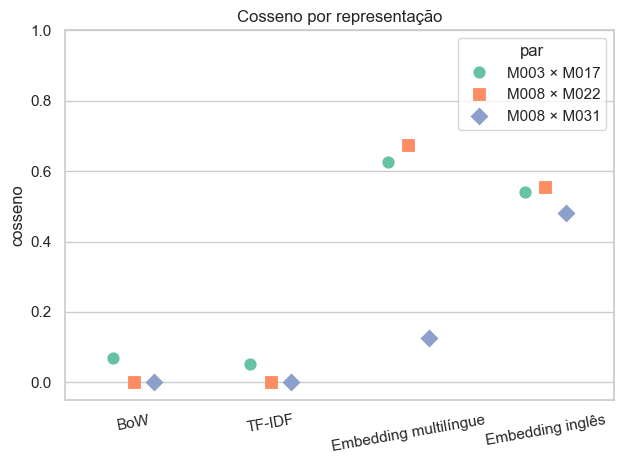

In [4]:
longo = resultado.reset_index(names="par").melt(id_vars="par", var_name="representação", value_name="cosseno")
ax = sns.pointplot(data=longo, x="representação", y="cosseno", hue="par", dodge=0.3, markers=["o", "s", "D"],
                   linestyles="none", palette="Set2")
ax.set_ylim(-0.05, 1); ax.set_xlabel(""); ax.set_title("Cosseno por representação")
plt.xticks(rotation=10); plt.tight_layout(); plt.show()

### Parte C · Por que BoW e TF-IDF erram: o vocabulário em comum

In [5]:
analisar = bow.build_analyzer()
pd.DataFrame([{
    "par": f"{a} × {b}",
    "termos em comum": ", ".join(sorted(set(analisar(base.texto[pos[a]])) & set(analisar(base.texto[pos[b]])))) or "nenhum",
    a: base.texto[pos[a]], b: base.texto[pos[b]],
} for a, b in PARES]).iloc[:, :2]

,par,termos em comum
0,M003 × M017,carros
1,M008 × M022,nenhum
2,M008 × M031,nenhum


### Parte D · A representação separa os temas?
Se capturar o assunto, a similaridade média entre manifestações da **mesma** categoria oficial deve superar a média entre categorias **diferentes**.

In [6]:
cat = base["categoria_oficial"].to_numpy()
mesma = cat[:, None] == cat[None, :]
fora = ~np.eye(len(cat), dtype=bool)
pd.DataFrame({nome: {"mesma categoria": S[mesma & fora].mean(), "categorias diferentes": S[~mesma].mean(),
                     "separação": S[mesma & fora].mean() - S[~mesma].mean()}
              for nome, S in matrizes.items()}).T.round(3)

,mesma categoria,categorias diferentes,separação
BoW,0.068,0.022,0.046
TF-IDF,0.044,0.014,0.030
Embedding multilíngue,0.416,0.217,0.199
Embedding inglês,0.518,0.462,0.056


## Conclusão

**Resultados (cosseno):**

| Par | BoW | TF-IDF | Emb. multilíngue | Emb. inglês |
|---|---|---|---|---|
| M003 × M017 (buraco × asfalto esburacado) | 0,069 | 0,051 | **0,626** | 0,542 |
| M008 × M022 (posto sem médico × falta atendimento no PSF) | 0,000 | 0,000 | **0,674** | 0,554 |
| M008 × M031 (posto sem médico × lâmpada queimada) | 0,000 | 0,000 | **0,125** | 0,480 |

**BoW e TF-IDF** só enxergam palavras idênticas. M008 e M022 falam do mesmo problema, mas não têm **nenhum** termo em comum ("médico" × "doutor", "posto de saúde" × "PSF", "consulta" × "consultar"), e a similaridade é exatamente zero, a mesma do par sem relação M008 × M031. Em M003 × M017 o único termo compartilhado é "carros"; "buraco" e "buracos"/"esburacado" contam como palavras diferentes. O TF-IDF ainda reduz esse valor porque pondera pela raridade, mas não resolve o problema de fundo: representações esparsas (3,4% de densidade aqui) não têm noção de sinônimo nem de flexão. Com elas, as duplicatas da ouvidoria passam despercebidas, exatamente o problema relatado pela prefeitura.

**Embeddings multilíngues** acertam os três casos: 0,63 e 0,67 nos pares que descrevem o mesmo problema e 0,13 no par sem relação, uma margem de mais de 0,5. Na visão geral, a similaridade média entre manifestações da mesma categoria (0,42) é quase o dobro da média entre categorias diferentes (0,22), sinal de que o espaço vetorial organiza os textos por tema.

**O modelo em inglês** (`all-MiniLM-L6-v2`) mostra que o modelo importa: ele dá 0,48 para posto de saúde × lâmpada queimada, quase o mesmo valor dos pares duplicados, e separa pouco as categorias (0,52 × 0,46). Como não foi treinado em português, quebra as palavras em pedaços de subpalavra sem significado e acaba aproximando qualquer texto em português.

**Limitações:** BoW e TF-IDF são rápidos, interpretáveis e úteis para termos exatos (nomes de ruas, protocolos), mas falham com sinônimos, siglas (PSF) e flexões. Embeddings capturam o significado, mas dependem do idioma do modelo, custam mais para calcular e não explicam por que dois textos são parecidos. Para a triagem da ouvidoria, a escolha é um **modelo multilíngue**, possivelmente combinado com busca léxica para nomes de logradouros.